In [1]:
# read the power generation profile per time step

import csv
import os
import sys
import numpy as np
import pandas as pd

# data file name

file_name = os.path.join(os.getcwd(), 'data', 'MD05E070207A1  data_power gen_single cell_Liu_20260421.xlsx')

# read the data from the csv file
time_steps = []
power_generation = []

df = pd.read_excel(file_name, sheet_name='Sheet1')

# extract the power generation data 
power_generation_data = df['Qbat(W)'].values[1:]


In [2]:
import numpy as np
from io import StringIO

types = (
    ('avg', 'MD05E070210A2  data_aircooling BTMS_temperature_avg.out'),
    ('max', 'MD05E070211A2  data_aircooling BTMS_temperature_max.out'),
    ('min', 'MD05E070212A2  data_aircooling BTMS_temperature_min.out')
)

temperature_cfd_data = {}  # dictionary to store CFD temperature data for each type

for t, file_name in types:
    file_name_cfd = os.path.join(os.getcwd(), 'data', file_name)

    # Parse the Fluent report file: skip header lines starting with '"' and '(', read space-separated columns
    with open(file_name_cfd, 'r') as f:
        lines = [line.strip() for line in f if line.strip() and not line.strip().startswith('"') and not line.strip().startswith('(')]

    data_cfd = np.loadtxt(StringIO('\n'.join(lines)))
    time_step_cfd = data_cfd[:, 0].astype(int)
    flow_time_cfd = data_cfd[:, 1]
    report_def_0_cfd = data_cfd[:, 2]  # avg battery temperature from CFD [K]
    
    temperature_cfd_data[t] = (flow_time_cfd, report_def_0_cfd)


In [3]:
dt = 1 # time step in seconds

# battery parameters foundin [[parkpark2025RefinedAircooled]]
T_bat_init = 25 # initial battery temperature in Celsius
cp_bat = 830 # specific heat capacity of the battery in J/(kg°C) 
m_bat = 48e-3 # mass of the battery in kg
D_bat = 18e-3 # diameter of the battery in meters
H_bat = 65e-3 # height of the battery in meters
A_battery = np.pi * D_bat * H_bat # surface area of the battery in m^2

# calculate the battery temperature over time
T_bat = np.zeros(len(power_generation_data))
T_bat[0] = T_bat_init

for i in range(1, len(power_generation_data)):
    # calculate the temperature change based on the power generation and battery parameters
    dT = (power_generation_data[i-1] * dt) / (m_bat * cp_bat)
    T_bat[i] = T_bat[i-1] + dT      


In [4]:
# Žukauskas Nusellet correlation for natural convection from a horizontal cylinder
def zukauskas_nusellet(Re, Pr, *args):
    '''
    Calculate the Nusselt number for natural convection from a horizontal cylinder using the Žukauskas Nusellet correlation.
    Found eq. 19 in [[parkpark2025RefinedAircooled]].
    Parameters:
    Re: Reynolds number
    Pr: Prandtl number
    args: additional arguments for the correlation (e.g., correction factor)
    Returns:
    Nu: Nusselt number

    '''
    eps = args[0]  # correction factor for the Nusselt number
    Pr_s = args[1]  # Prandtl number at the surface temperature

    if Re > 0 and Re < 500:
       Nu = eps * 1.04 * (Re ** 0.4) * (Pr ** 0.36) * (Pr / Pr_s) ** 0.25
    elif Re >= 500 and Re < 1000:
        Nu = eps * 0.71 * (Re ** 0.5) * (Pr ** 0.36) * (Pr / Pr_s) ** 0.25
    elif Re >= 1000 and Re < 2e5:
        Nu = eps * 0.193 * (Re ** 0.62) * (Pr ** 0.36) * (Pr / Pr_s) ** 0.25
    else:
        Nu = eps * 0.027 * (Re ** 0.8) * (Pr ** 0.36) * (Pr / Pr_s) ** 0.25
        
    return Nu

In [5]:
# select the correction factor based on battery arrangement (in terms of number of columns) and Reynolds number
def select_correction_factor(no_col, Re):
    """
    Return correction factor eps for tube bank/cell-column arrangements.

    Data source (from your referenced table):
    - 1e2 < Re < 1e3
    - Re > 1e3
    with columns 1..9.

    Parameters
    ----------
    no_col : int
        Number of columns in the battery arrangement (1 to 9).
    Re : float
        Reynolds number based on battery diameter.

    Returns
    -------
    float
        Correction factor eps.
    """
    if no_col < 1:
        raise ValueError("no_col must be >= 1")

    # Clamp to available tabulated range [1, 9].
    col = int(round(no_col))
    col = max(1, min(9, col))
    idx = col - 1

    eps_1e2_to_1e3 = [0.832, 0.874, 0.914, 0.939, 0.955, 0.963, 0.970, 0.976, 0.980]
    eps_gt_1e3 = [0.619, 0.758, 0.840, 0.897, 0.923, 0.942, 0.954, 0.965, 0.971]

    # Piecewise selection with linear blending across the transition region.
    if Re <= 1e2:
        eps = eps_1e2_to_1e3[idx]
    elif Re < 1e3:
        eps = eps_1e2_to_1e3[idx]
    elif Re > 1e3:
        eps = eps_gt_1e3[idx]
    else:  # Re == 1e3
        eps = 0.5 * (eps_1e2_to_1e3[idx] + eps_gt_1e3[idx])

    return eps

In [6]:
# solve coolant temperture distribution using a 1D finite difference approach along the flow direction

import scipy.optimize as opt
import copy
import CoolProp.CoolProp as CP

def cal_power_residual(T_cool, args):
    
    T_bat = args.get("T_bat")
    T_cool_pre = args.get("T_cool_pre")
    u_cool = args.get("u_cool")
    p_cool = args.get("p_cool")
    fluid_cool = args.get("fluid_cool")
    A_battery = args.get("A_battery")
    A_cool = args.get("A_cool")
    D_bat = args.get("D_bat")
    num_seg = args.get("num_seg")
    T_cool_in = args.get("T_cool_in")
    is_cool = args.get("is_cool")
    Q_gen = args.get("Q_gen")
    debug = args.get("debug", False)
        
    residual = np.zeros(num_seg)  # initialize residual array for each segment

    for i in range(num_seg): 

        # calculate the Prandtl number at the surface temperature (battery temperature) and the inlet coolant temperature for this segment
    
        T_cool_pre_bar = ((T_cool_in if i == 0 else T_cool_pre[i-1]) + T_cool_pre[i]) / 2  # inlet coolant temperature for this segment

        T_cool_pre_k = T_cool_pre_bar  + 273.15 # use the inlet coolant temperature for this segment as the reference for calculating the coolant properties
        cp_cool = CP.PropsSI('C', 'T', T_cool_pre_k, 'P', p_cool, fluid_cool)  # specific heat capacity 
        mu_cool = CP.PropsSI('V', 'T', T_cool_pre_k, 'P', p_cool, fluid_cool)  # dynamic viscosity
        k_cool = CP.PropsSI('L', 'T', T_cool_pre_k, 'P', p_cool, fluid_cool)  # thermal conductivity
        rho_cool = CP.PropsSI('D', 'T', T_cool_pre_k, 'P', p_cool, fluid_cool)  # density of the coolant at the inlet temperature of this segment
        T_bat_cur = T_bat[i]
        Pr_cool = cp_cool * mu_cool / k_cool  # Prandtl number of the coolant at the inlet temperature of this segment
        
        Re_cool = (u_cool * D_bat) / (mu_cool / rho_cool)  # Reynolds number of the coolant at the inlet temperature of this segment
        
        Nu_cool = zukauskas_nusellet(Re_cool, Pr_cool, select_correction_factor(num_seg, Re_cool), Pr_cool)  # Nusselt number from the Žukauskas Nusellet correlation
        
        h_cool = Nu_cool * k_cool / D_bat  # convective heat transfer coefficient for this segment        
        
        if not is_cool:
            Q_cool_air = 0
          
        else:          
            Q_cool_air = h_cool * A_battery * (T_bat_cur - T_cool_pre_bar)  # use the average temperature between the current and inlet coolant temperature for heat transfer calculation

        dT_bat = (Q_gen - Q_cool_air) * dt / (m_bat * cp_bat)
        
        if debug:
            print(f"Segment {i}: Q_gen = {Q_gen}, Q_cool_air = {Q_cool_air}, dT_bat = {dT_bat}; T_bat_cur = {T_bat_cur}, T_cool_pre_bar = {T_cool_pre_bar}")  # debug print for power generation, cooling power, and battery temperature change for this segment

        T_bat_cur += dT_bat  # update the battery temperature for this segment based on the power generation and cooling power, this will be used for calculating the heat transfer coefficient and power transfer in the next iteration of the optimization solver

        # calculate the power received by the coolant via internal energy change
        T_cool_cur = T_cool_in if i == 0 else T_cool[i-1]  # inlet coolant temperature for this segment
        dT_cool = T_cool[i] - T_cool_cur  # temperature change of the coolant in this segment
        
        Q_to_bat = h_cool * A_battery * (T_bat_cur - (T_cool[i] + T_cool_cur) / 2)  # power transferred from the battery to the coolant based on the current battery temperature and average coolant temperature
        
        Q_from_cool = u_cool * A_cool * cp_cool * dT_cool
        
        # calculate the residual between the input power and the power received by the coolant
        residual[i]= abs(Q_to_bat - Q_from_cool) # should be close to zero when the coolant temperature distribution is correct
    
    if debug:
        print(f"heat transfer coefficient h_cool for this segment {i}: {h_cool}")  # debug print for the calculated heat transfer coefficient for this segment
        print(f"Current coolant temperatures: {T_cool}")  # debug print for the current coolant temperature distribution in this iteration
        print(f"Current residual: {residual}")  # debug print for the current residual in this iteration     
    return residual

def solve_coolant_temperature_distribution(T_bat, T_cool_pre, u_cool, p_cool, fluid_cool, A_cool, A_battery, D_bat, T_cool_in, T_cool_out, is_cool, Q_gen,tol=1e-6, maxiter=1000, debug=False):
        
    num_seg = len(T_bat)
    
    T_cool = np.linspace(T_cool_in, T_cool_out, num_seg+1)[1:]  # initial guess for coolant temperature distribution (linear from inlet to outlet temperature)
    
    print(f"Initial guess for {len(T_cool)} coolant temperatures along the flow path: {T_cool}")  # debug print for the initial guess of the coolant temperature distribution
    
    # T_cool_init = np.insert(T_cool_init, 0, T_cool_in)  # insert inlet temperature at the beginning of the coolant temperature array

    upper_bound = np.ones(num_seg) * (T_cool_in + 300) # set an upper bound for the coolant temperature distribution for the optimization solver, adjust as needed
    
    lower_bound = np.ones(num_seg) * T_cool_in # set a lower bound for the coolant temperature distribution for the optimization solver, adjust as needed
    
    args = {
        "T_bat": T_bat, 
        "T_cool_pre": T_cool_pre,
        "u_cool": u_cool,
        "p_cool": p_cool,
        "fluid_cool": fluid_cool,
        "A_battery": A_battery,
        "A_cool": A_cool,
        "D_bat": D_bat,
        "num_seg": num_seg,
        "T_cool_in": T_cool_in,
        "is_cool": is_cool,
        "Q_gen": Q_gen,
        "debug": debug
    }
    
    res = opt.least_squares(        
        cal_power_residual, 
        T_cool, 
        args=([args]), 
        method ='trf', 
        verbose=2,
        ftol=tol, max_nfev=maxiter,
        bounds=(lower_bound, upper_bound)
    )
    
    # output the battery temperature and coolant temperature distribution for debugging

    if debug:
        print("Optimization success:", res.success)
        print("Final residual:", res.fun)        
        print("Optimized coolant temperatures:", res.x)
    
    return res.x

In [7]:

# Initial conditions and parameters

# V_air_nom = 241 # nominal air velocity in km/h for the cooling system (example value, adjust as needed)
# V_air = V_air_nom / 3.6 # convert nominal air velocity to m/s

V_air = 1.5 # example air velocity for testing (adjust as needed)
# V_air = [0.1 # air velocity in m/s 

T_air = 25 # ambient air temperature in Celsius
T_air_K = T_air + 273.15 # convert to Kelvin

p_air = 101325 # ambient air pressure in Pa

N_r, N_c = 16, 20 # number of rows and columns in the battery arrangement for a single module (example values, adjust as needed)

S_T = 1.25 * D_bat # spacing between battery rows in meters (example value, adjust as needed)

W_module = D_bat + (N_r - 1) * S_T # width of the battery module in meters (example calculation, adjust as needed)

A_air = W_module * H_bat # cross-sectional area of a single module of the air flow path in m^2

fluid = 'Air'

t_cruise_start = 180 # time step when the cruise phase starts (example value, adjust as needed)
t_cruise_end = 1560 # time step when the cruise phase ends (example value, adjust as needed)


In [8]:
# calculate the battery temperature profile when introducing an air cooling system
import CoolProp.CoolProp as CP
# Calculate the Prandtl number for air at ambient conditions
mu_air = CP.PropsSI('V', 'T', T_air_K, 'P', p_air, fluid) # dynamic viscosity of air in kg/(m·s)
rho_air = CP.PropsSI('D', 'T', T_air_K, 'P', p_air, fluid) # density of air in kg/m^3
cp_air = CP.PropsSI('C', 'T', T_air_K, 'P', p_air, fluid) # specific heat capacity of air in J/(kg·K)
Pr_air = cp_air * mu_air / CP.PropsSI('L', 'T', T_air_K, 'P', p_air, fluid) # Prandtl number for air

# Calculate the Reynolds number for the air flow over the battery
Re_air = (rho_air * V_air * D_bat) / mu_air

# battery temperature under air cooling
T_bat_air_0D = np.zeros(len(power_generation_data))
T_bat_air_0D[0] = T_bat_init
T_air_out = np.zeros(len(power_generation_data)) # to store the outlet air temperature for analysis
T_air_out[0] = T_air # initial outlet air temperature is the same as inlet air temperature
t = 0 # initialize time variable


Q_cool_air_profile = np.zeros(len(power_generation_data)) # to store the cooling power profile for analysis

for i in range(1, len(power_generation_data)):
    
    # enable the air cooling in the cruise phase only 
    
    if t < t_cruise_start or t > t_cruise_end:
        Q_cool_air = 0    
        T_air_out[i] = T_air # outlet air temperature is the same as inlet air temperature when no cooling occurs
    
    else:    
        # calculate the Prandtl number at the battery surface temperature
        T_bat_K = T_bat_air_0D[i-1] + 273.15 # convert to Kelvin
        cp_bat_surface = CP.PropsSI('C', 'T', T_bat_K, 'P', p_air, fluid) # specific heat capacity of air at the battery surface temperature in J/(kg·K)
        mu_bat_surface = CP.PropsSI('V', 'T', T_bat_K, 'P', p_air, fluid) # dynamic viscosity of air at the battery surface temperature in kg/(m·s)
        Pr_bat_surface = cp_bat_surface * mu_bat_surface / CP.PropsSI('L', 'T', T_bat_K, 'P', p_air, fluid)
        
        eps = select_correction_factor(no_col=9, Re=Re_air) # select the correction factor for a single column arrangement and the calculated Reynolds number
        Nu_air = zukauskas_nusellet(Re_air, Pr_air, eps, Pr_bat_surface) # calculate the Nusselt number using the Žukauskas Nusellet correlation
        
        k_air = CP.PropsSI('L', 'T', T_air_K, 'P', p_air, fluid) # thermal conductivity of air in W/(m·K)
        h_air = (Nu_air * k_air) / D_bat # convective heat transfer coefficient in W/(m^2·K)
        # calculate the cooling power provided by the air cooling system
        Q_cool_air = h_air * A_battery * (T_bat_air_0D[i-1] - T_air) # cooling power in W
        h_air_in = CP.PropsSI('H', 'T', T_air_K, 'P', p_air, fluid) # enthalpy of air at inlet conditions in J/kg
        h_air_out = h_air_in + Q_cool_air * N_c * N_r / (rho_air * V_air * A_air) # enthalpy of air at outlet conditions in J/kg
        T_air_out[i] = CP.PropsSI('T', 'H', h_air_out, 'P', p_air, fluid) - 273.15 # convert to Celsius and store the outlet air temperature for analysis

    Q_cool_air_profile[i] = Q_cool_air # store the cooling power for analysis
    # calculate the temperature change based on the power generation, battery parameters, and air cooling
    dT = (power_generation_data[i-1] - Q_cool_air) * dt / (m_bat * cp_bat)
    T_bat_air_0D[i] = T_bat_air_0D[i-1] + dT
    
    t = t + dt # update time variable


In [9]:
# calculate the battery temperature changes over the time steps based on the power generation and the cooling effect of the air flow

import CoolProp.CoolProp as CP

# Calculate the Prandtl number for air at ambient conditions
mu_air = CP.PropsSI('V', 'T', T_air_K, 'P', p_air, fluid) # dynamic viscosity of air in kg/(m·s)
rho_air = CP.PropsSI('D', 'T', T_air_K, 'P', p_air, fluid) # density of air in kg/m^3
cp_air = CP.PropsSI('C', 'T', T_air_K, 'P', p_air, fluid) # specific heat capacity of air in J/(kg·K)
Pr_air = cp_air * mu_air / CP.PropsSI('L', 'T', T_air_K, 'P', p_air, fluid) # Prandtl number for air

# Calculate the Reynolds number for the air flow over the battery
Re_air = (rho_air * V_air * D_bat) / mu_air

# battery temperature distribution with air cooling over time steps

num_segment = N_c # number of segments for the finite difference method along the flow direction, adjust as needed
T_bat_air_history = np.empty(num_segment, dtype=object) # initialize the battery temperature history for each segment as an empty list

T_air_dist_pre = np.ones(num_segment) * T_air # initial air temperature distribution along the flow direction (uniform at ambient temperature)

num_time_steps = len(power_generation_data) # number of time steps to simulate, adjust as needed

for i in range(num_segment):
    T_bat_air_history[i] = np.zeros(num_time_steps)
    T_bat_air_history[i][0] = T_bat_init # set the initial battery temperature for each segment in the history

debug = False

t = 0 # initialize time variable

for i in range(1, num_time_steps):
    print(f"****** Time step {i}: t = {t} seconds ******")  # debug print for the current time step and time variable
    # calculate the Nusselt number using the Žukauskas Nusellet correlation
    eps = select_correction_factor(no_col=1, Re=Re_air)  # example with 1 column, adjust as needed
    Nu_air = zukauskas_nusellet(Re_air, Pr_air, eps, Pr_air)
    
    # calculate the convective heat transfer coefficient
    k_air = CP.PropsSI('L', 'T', T_air_K, 'P', p_air, fluid) # thermal conductivity of air in W/(m·K)
    h_global = (Nu_air * k_air) / D_bat # global convective heat transfer coefficient in W/(m^2·K)
    
    # solve for the coolant temperature distribution and battery temperature distribution
    # extract the current battery temperature distribution from the history
    T_bat_air_cur = np.zeros(num_segment)
    T_bar_air_next = np.zeros(num_segment) # initialize the battery temperature distribution for the next time step
    
    for j in range(num_segment):
        # if debug:
        #     print(f"Time step {i}, Segment {j}: T_bat_air_history = {T_bat_air_history[j][i]}")  # debug print for battery temperature history  
        T_bat_air_cur[j] = T_bat_air_history[j][i-1]
        
    # print T_bat_air_cur for debugging
    
    print(f"Time step {i}(before): T_bat_air_cur = {T_bat_air_cur}")
    
    is_cooling = (t >= t_cruise_start) and (t <= t_cruise_end)  # determine if cooling is active based on the current time step
    
    A_air_row = A_air / N_r # cross-sectional area of the air flow path for each row of the battery arrangement in m^2
    
  
    T_cool_air = solve_coolant_temperature_distribution(
        T_bat=copy.deepcopy(T_bat_air_cur),  # use the current battery temperature distribution as input for solving the coolant temperature distribution, use deepcopy to avoid modifying the original battery temperature distribution during the optimization process
        T_cool_pre =T_air_dist_pre,
        u_cool = V_air,
        p_cool = p_air,
        fluid_cool = fluid,
        A_cool = A_air_row,
        A_battery = A_battery,
        D_bat = D_bat,
        T_cool_in = T_air,
        T_cool_out = T_air_out[i], # use the calculated outlet air temperature for this time step as the outlet temperature for solving the coolant temperature distribution
        is_cool = is_cooling,
        Q_gen = power_generation_data[i],
        tol = 1e-3,
        maxiter = 1000,
        debug = debug
    )
    
    print(f"Time step {i}(after): T_cool_air = {T_cool_air}")  # debug print for the solved coolant temperature distribution

    
    for j in range(num_segment):
        
        if j == 0:
            Q_cool = (T_cool_air[j] - T_air) * A_air_row * cp_air * V_air  # temperature difference across the segment for heat transfer calculation
        else:            
            Q_cool = (T_cool_air[j] - T_cool_air[j-1]) * A_air_row * cp_air * V_air  # temperature difference across the segment for heat transfer calculation
        
        if(Q_cool < 0):
            Q_cool = 0 # no cooling effect if the calculated cooling power is negative (i.e., if the coolant temperature increases along the flow direction)
        Q_bat = (power_generation_data[i] - Q_cool) * dt # total energy left on battery in the current time step
        
        dT_bat = Q_bat / (m_bat * cp_bat) # temperature change of the battery in the current time step
        T_bar_air_next[j] = T_bat_air_cur[j] + dT_bat # update the battery temperature distribution for the next time step with the new temperature after cooling and power generation effects
        T_bat_air_history[j][i] = T_bar_air_next[j] # update the battery temperature history for the current time step with the new temperature distribution after cooling and power generation effects
        
        # if debug:
        #     print(f"Time step {i}, Segment {j}: Q_cool = {Q_cool}, Q_bat = {Q_bat}, dT_bat = {dT_bat}, T_bat_air_cur = {T_bat_air_cur[j]}, T_bar_air_next = {T_bar_air_next[j]}")  # debug print for cooling power, battery power, and temperature change
        
    
    # print(f"Time step {i}: T_bar_air_next = {T_bar_air_next}")  # debug print for updated battery temperature distribution after cooling and power generation effects
    t += dt
    T_air_dist_pre = copy.deepcopy(T_cool_air)  # update the previous air temperature distribution for the next time step, exclude the inlet temperature which is constant at ambient temperature


****** Time step 1: t = 0 seconds ******
Time step 1(before): T_bat_air_cur = [25. 25. 25. 25. 25. 25. 25. 25. 25. 25. 25. 25. 25. 25. 25. 25. 25. 25.
 25. 25.]
Initial guess for 20 coolant temperatures along the flow path: [25. 25. 25. 25. 25. 25. 25. 25. 25. 25. 25. 25. 25. 25. 25. 25. 25. 25.
 25. 25.]
   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         3.9530e-04                                    4.20e+00    
       1              2         5.6199e-12      3.95e-04       1.15e-01       5.37e-04    
       2              5         3.6091e-12      2.01e-12       1.11e-05       2.54e-04    
       3              8         3.2666e-12      3.42e-13       7.06e-07       2.46e-04    
`xtol` termination condition is satisfied.
Function evaluations 8, initial cost 3.9530e-04, final cost 3.2666e-12, first-order optimality 2.46e-04.
Time step 1(after): T_cool_air = [25.00282515 25.00553558 25.00813595 25.01063073 25.01302

KeyboardInterrupt: 

<Figure size 1000x600 with 0 Axes>

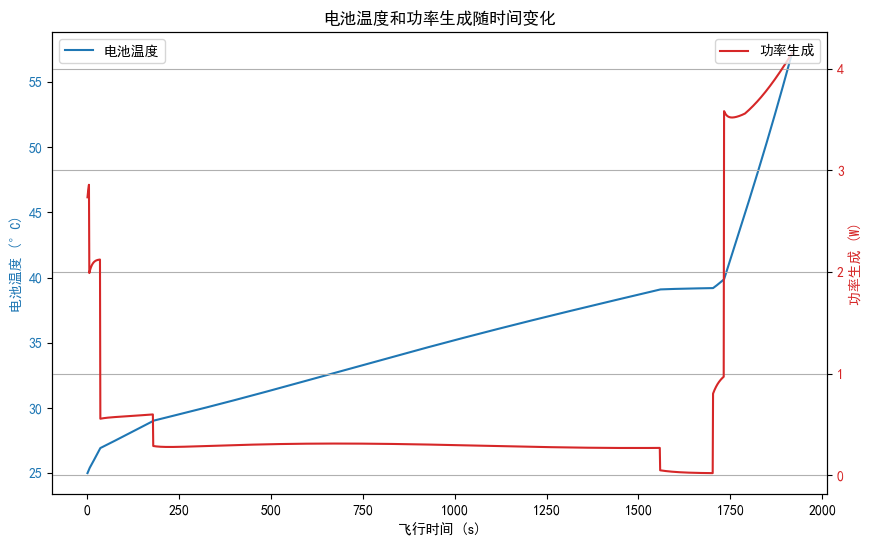

In [ ]:
# in this part, plot the battery temperature profile over time steps with and without air cooling, and the power generation profile for analysis

import matplotlib.pyplot as plt
# Add support to display Chinese characters in the plot
plt.rcParams['font.sans-serif'] = ['SimHei']  # Use SimHei font for Chinese characters
plt.rcParams['axes.unicode_minus'] = False  # Ensure that

plt.figure(figsize=(10, 6))

time_array = np.arange(len(power_generation_data)) * dt  # create an array of time values corresponding to the time steps

# remove the last time step which contains an error
time_array = time_array[:-1]
T_bat_plot = T_bat[:-1]
power_plot = power_generation_data[:-1]  

# plot two y-axes for battery temperature and power generation
fig, ax1 = plt.subplots(figsize=(10, 6))
color = 'tab:blue'
ax1.set_xlabel('飞行时间 (s)')
ax1.set_ylabel('电池温度 (°C)', color=color)
ax1.plot(time_array, T_bat_plot, label='电池温度', color=color, linestyle='-')
ax1.tick_params(axis='y', labelcolor=color)
ax1.legend(loc='upper left')    
ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis
color = 'tab:red'
ax2.set_ylabel('功率生成 (W)', color=color)  # we already handled the x-label with ax1
ax2.plot(time_array, power_generation_data[:-1], label='功率生成', color=color, linestyle='-')
ax2.tick_params(axis='y', labelcolor=color)
ax2.legend(loc='upper right')
plt.title('电池温度和功率生成随时间变化')
plt.grid()
plt.show()

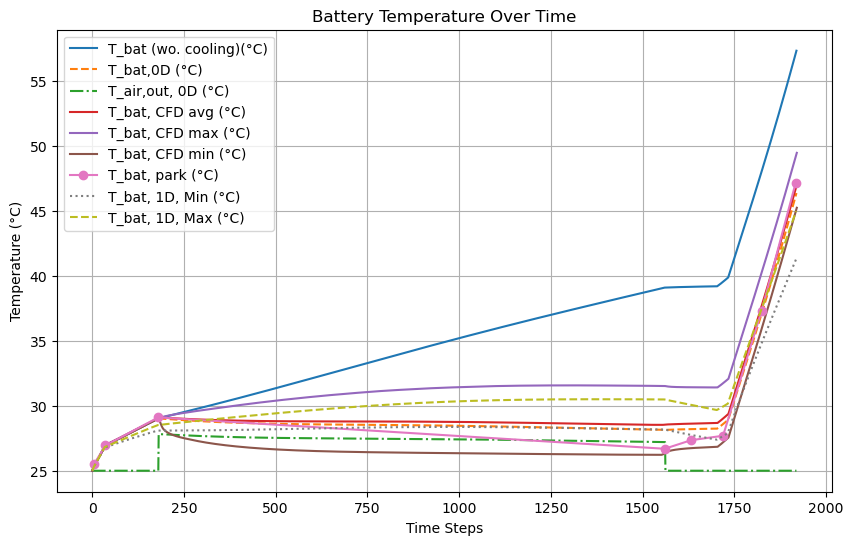

In [ ]:
# plot the battery temperature over time
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(T_bat, label='T_bat (wo. cooling)(°C)')
# plot the battery temperature under air cooling as a dashed line
plt.plot(T_bat_air_0D, label='T_bat,0D (°C)', linestyle='--')

# plot the air outlet temperature profile for analysis
plt.plot(T_air_out, label='T_air,out, 0D (°C)', linestyle='-.') # convert to Celsius for plotting

# plot the CFD temperature data for comparison
for t, (flow_time_cfd, report_def_0_cfd) in temperature_cfd_data.items():
    plt.plot(flow_time_cfd, report_def_0_cfd - 273.15, label=f'T_bat, CFD {t} (°C)') # convert CFD temperature from K to °C for plotting   

# plot the band between the max and min CFD temperatures to visualize the range of CFD predictions
# plt.fill_between(temperature_cfd_data['min'][0], temperature_cfd_data['min'][1] - 273.15, temperature_cfd_data['max'][1] - 273.15, color='gray', alpha=0.3, label='CFD Temperature Range (°C)') # convert CFD temperatures from K to °C for plotting

# plot the experimental temperature data from Park's paper for comparison
t_park = [6, 36, 180, 1560, 1632, 1719, 1824, 1917]
T_park = [298.7, 300.1, 302.25, 299.84, 300.5, 300.84, 310.45, 320.31] # Park's experimental temperature data in Kelvin

plt.plot(t_park, np.array(T_park) - 273.15, label='T_bat, park (°C)', marker='o') # convert Park's temperature from K to °C for plotting

# plot the battery temperature calculated using the one-dimensional finite difference method for the air cooling case as a dashed line
T_bat_air_fd_min = T_bat_air_history[0] # minimum battery temperature across segments at each time step
T_bat_air_fd_max = T_bat_air_history[-1] # maximum battery temperature across segments at each time step

plt.plot(T_bat_air_fd_min[:-1], label='T_bat, 1D, Min (°C)', linestyle=':') # plot the minimum battery temperature across segments as a dotted line
plt.plot(T_bat_air_fd_max[:-1], label='T_bat, 1D, Max (°C)', linestyle='--') # plot the maximum battery temperature across segments as a dotted line
# plt.fill_between(range(len(T_bat_air_0D)), T_bat_air_fd_min, T_bat_air_fd_max, color='blue', alpha=0.1, label='Battery Temperature Range with Air Cooling (1D FD) (°C)') # fill the area between the minimum and maximum battery temperatures across segments to visualize the range of temperatures predicted by the 1D finite difference method

plt.xlabel('Time Steps')
plt.ylabel('Temperature (°C)')
plt.title('Battery Temperature Over Time')
plt.legend()
plt.grid()
plt.show()

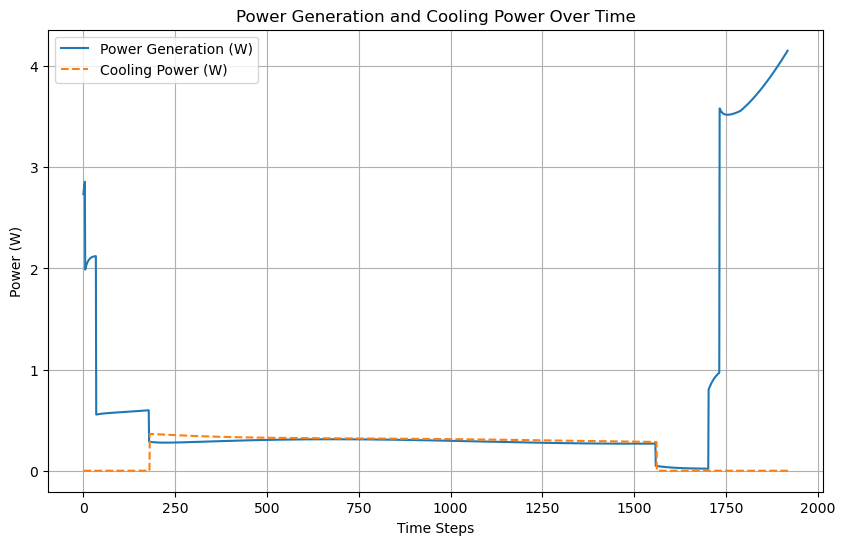

In [ ]:
# plot the power generation and cooling power profiles
plt.figure(figsize=(10, 6))
plt.plot(power_generation_data, label='Power Generation (W)')
plt.plot(Q_cool_air_profile, label='Cooling Power (W)', linestyle='--')
plt.xlabel('Time Steps')
plt.ylabel('Power (W)')
plt.title('Power Generation and Cooling Power Over Time')
plt.legend()
plt.grid()
plt.show()